Queremos buscar una barrera que permita que pasen, como máximo. 0.01% de los KIENES incidentes, es decir, T<$10^{-4}$

Suponiendo que la energía de los KIENES es como máximo 0.1 eV, he ido cambiando la longitud de la barrera y me he quedado con el valor del coeficiente de transmisión para esa energía.

Voy a guardar los coeficientes de transmisión para materiales distintos:
- GaAs con masa efectiva de  0.063 me
- InAs con masa efectiva de 0.023me
- InP con masa efectiva de 0.08 me
- InSb con masa efectiva de 0.014 me

La longitud mínima de la barrera tienen que ser 15 nanómetros, así que creo que va a estar jodido respaldar que tenemos que utilizar InSb, pero ya iremos viendo

In [38]:
import numpy as np
import matplotlib.pyplot as plt

Energia = 0.1
Barreramax = 0.3
hbarrac = 197.3269    # eV*nm
m0c2 = 511000   # eV

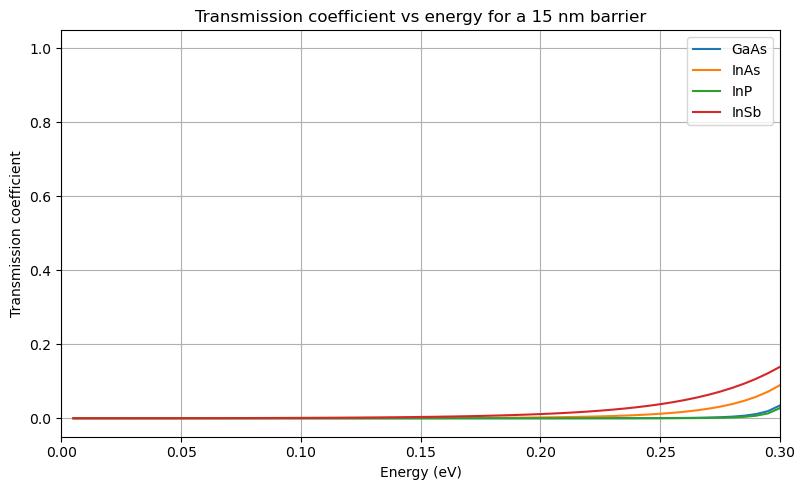

In [39]:
# =========================================================
# ARCHIVOS
# =========================================================
archivos = {
    "GaAs": "GaAs15.txt",
    "InAs": "InAs15.txt",
    "InP":  "InP15.txt",
    "InSb": "InSb15.txt",
}

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(8, 5))

for material, nombre_archivo in archivos.items():

    # Lee el txt saltándose la primera línea
    # delimiter="," porque las columnas están separadas por coma
    datos = np.loadtxt(nombre_archivo, delimiter=",", skiprows=1)

    T = datos[:, 0]   # Transmission Coefficient
    E = datos[:, 1]   # Energy (eV)

    plt.plot(E, T, label=material)

# =========================================================
# FORMATO
# =========================================================
plt.xlabel("Energy (eV)")
plt.ylabel("Transmission coefficient")
plt.title("Transmission coefficient vs energy for a 15 nm barrier")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 0.3)

plt.show()

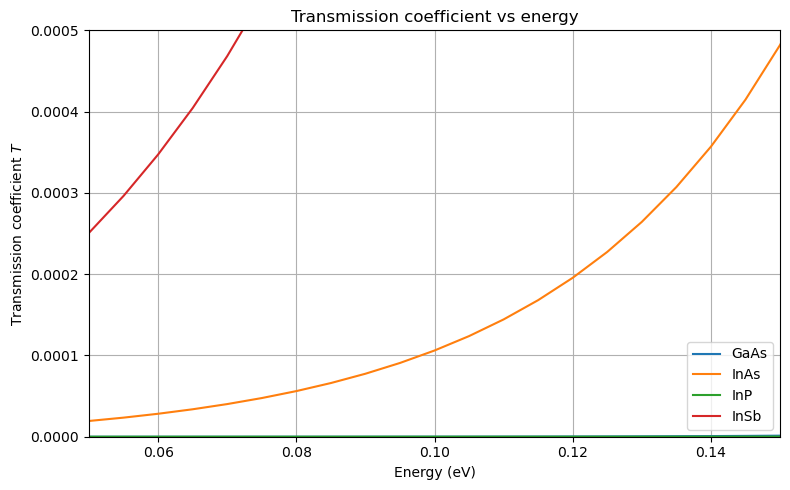

In [40]:
import numpy as np
import matplotlib.pyplot as plt

archivos = {
    "GaAs": "GaAs15.txt",
    "InAs": "InAs15.txt",
    "InP":  "InP15.txt",
    "InSb": "InSb15.txt",
}

masas = np.array([0.063, 0.023, 0.08, 0.014])   # masas efectivas




plt.figure(figsize=(8, 5))

for material, nombre_archivo in archivos.items():

    datos = np.loadtxt(nombre_archivo, delimiter=",", skiprows=1)

    T = datos[:, 0]
    E = datos[:, 1]

    plt.plot(E, T, label=material)   # escala normal

plt.xlim(0.05, 0.15)
plt.ylim(0, 0.0005)

plt.xlabel("Energy (eV)")
plt.ylabel(r"Transmission coefficient $T$")
plt.title("Transmission coefficient vs energy")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

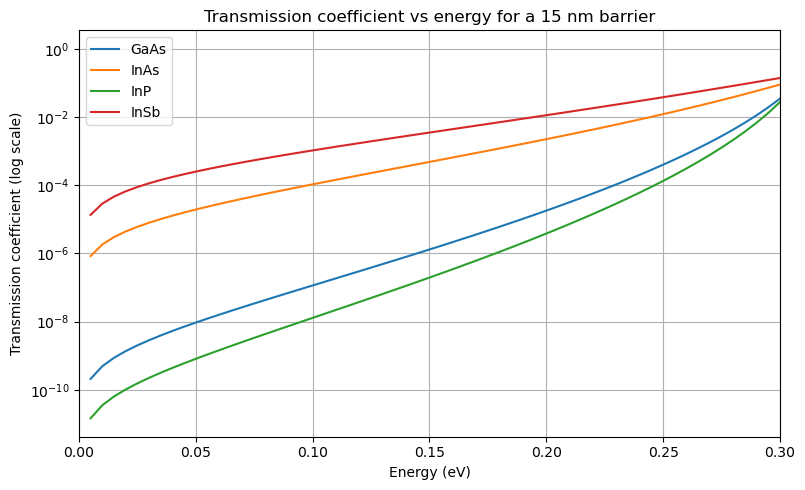

In [41]:

plt.figure(figsize=(8, 5))

for material, nombre_archivo in archivos.items():

    datos = np.loadtxt(nombre_archivo, delimiter=",", skiprows=1)

    T = datos[:, 0]
    E = datos[:, 1]

    plt.semilogy(E, T, label=material)

plt.xlabel("Energy (eV)")
plt.ylabel("Transmission coefficient (log scale)")
plt.title("Transmission coefficient vs energy for a 15 nm barrier")

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.xlim(0,0.3)

plt.show()

C:\Users\Teresa\AppData\Local\Temp\ipykernel_19236\1994702062.py:2: RuntimeWarning: divide by zero encountered in divide
  cte1 = (0.3**2) / (4 * E * (0.3 - E))
C:\Users\Teresa\AppData\Local\Temp\ipykernel_19236\1994702062.py:3: RuntimeWarning: invalid value encountered in sqrt
  cte2 = np.sqrt(2 * m * m0c2 * (0.3 - E)) * 15 / hbarrac
C:\Users\Teresa\AppData\Local\Temp\ipykernel_19236\1994702062.py:5: RuntimeWarning: invalid value encountered in multiply
  return 1 / (1 + cte1 * np.sinh(cte2)**2)


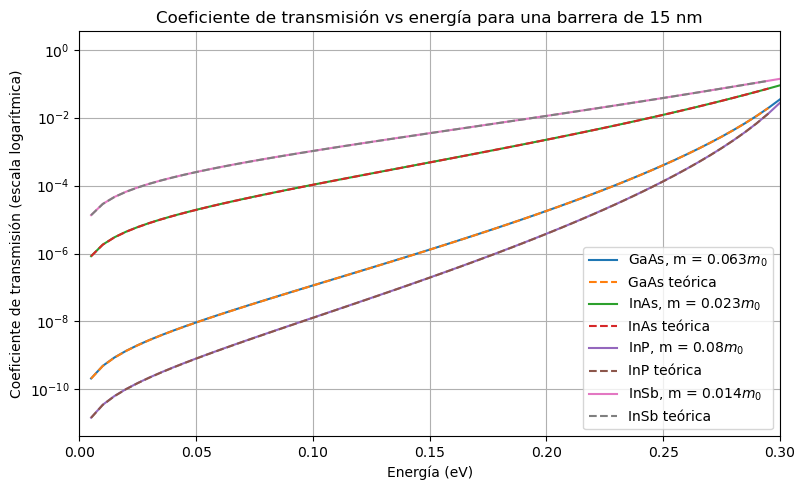

In [46]:
def transmision(E, m):
    cte1 = (0.3**2) / (4 * E * (0.3 - E))
    cte2 = np.sqrt(2 * m * m0c2 * (0.3 - E)) * 15 / hbarrac

    return 1 / (1 + cte1 * np.sinh(cte2)**2)


plt.figure(figsize=(8, 5))

i = 0

for material, nombre_archivo in archivos.items():

    datos = np.loadtxt(nombre_archivo, delimiter=",", skiprows=1)

    T = datos[:, 0]
    E = datos[:, 1]

    plt.semilogy(E, T, label=material + ", m = " + str(masas[i]) + r"$m_0$")
    plt.semilogy(E, transmision(E, masas[i]), "--", label=material + " teórica")

    i += 1

plt.xlabel("Energía (eV)")
plt.ylabel("Coeficiente de transmisión (escala logarítmica)")
plt.title("Coeficiente de transmisión vs energía para una barrera de 15 nm")

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.xlim(0, 0.3)

plt.show()